# Proyecto Final - Informe Técnico

Grupo: Finanzas 


# 1. Problema Analítico

### 1.1. Descripción detallada del problema

El fraude en transacciones bancarias y de dinero móvil representa una amenaza crítica para la integridad de las plataformas financieras digitales. Este problema no solo afecta directamente al cliente (a través del robo de fondos o el bloqueo injustificado de sus cuentas) sino también a la institución financiera, generando pérdidas económicas, costos operacionales por resolución de reclamos, y daño reputacional de largo plazo.

A medida que el volumen de transacciones digitales crece, los mecanismos de detección basados en reglas fijas resultan insuficientes. Los defraudadores adaptan sus técnicas constantemente, lo que exige sistemas capaces de identificar patrones anómalos de forma dinámica y en tiempo real.

**El objetivo de este proyecto** es desarrollar un analisis exploratorio (insights) para posteriormente poder desarrollar un modelo de clasificación binaria supervisado que identifique transacciones potencialmente fraudulentas, entrenado con patrones históricos
y datos sintéticos representativos. 

### 1.2. Fuente de datos

**Dataset:** PaySim — Synthetic Financial Transactions for Fraud Detection

**Fuente:** [Kaggle - PaySim Dataset](https://www.kaggle.com/datasets/ealaxi/paysim1)  
**Referencia:** Lopez-Rojas, E., Elmir, A. & Axelsson, S. (2016). PaySim: A financial mobile money simulator for fraud detection. EMSS 2016.

**Descripción:**  
Este dataset contiene 6.3 millones de transacciones de dinero móvil simuladas con patrones reales de fraude (solo el 0.13% de los casos son fraudulentos). Para esta actividad se está trabajando con una **muestra aleatoria de 100,000 registros**.


**Variables:**  
|Variable | Descripción |
|---|---|
| `step` | Unidad de tiempo de la simulación: 1 step = 1 hora (el dataset cubre 744 steps o 30 días) |
| `type` | Tipo de operación realizada: CASH_IN, CASH_OUT, DEBIT, PAYMENT o TRANSFER | 
| `amount` | Monto de la transacción en la moneda local | 
| `nameOrig` | ID del cliente que origina la transacción | 
| `oldbalanceOrg` | Saldo de la cuenta originadora antes de ejecutarse la transacción | 
| `newbalanceOrig` | Saldo de la cuenta originadora después de ejecutarse la transacción |
| `nameDest` |ID del cliente o comercio que recibe la transacción | 
| `oldbalanceDest` | Saldo de la cuenta destinataria antes de recibir la transacción | 
| `newbalanceDest` | Saldo de la cuenta destinataria después de recibir la transacción | 
| `isFraud` | Indicador de fraude: 1 si la transacción fue ejecutada por un agente malicioso que tomó control de la cuenta, 0 si es legítima |
| `isFlaggedFraud` | Alerta automática del sistema PaySim si lo identifico como fraude |   
 

Variable type  
|Type | Descripción |
|---|---|
|CASH_IN | Ingresa dinero a su cuenta → su saldo sube|
|CASH_OUT | Retira efectivo → su saldo baja |
|DEBIT |Se debita su cuenta → su saldo baja | 
|PAYMENT | Paga a un comercio → su saldo baja|
|TRANSFER | Transfiere a otra cuenta → su saldo baja | 

Las variables monetarias (`amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`) constituyen el núcleo del análisis, ya que reflejan el comportamiento financiero antes y después de cada operación.

**Variable objetivo:** `isFraud` (0 = transacción legítima, 1 = fraude)  

**Pregunta analítica central:**  
¿Qué variables financieras (`amount`, `type`, `oldbalanceOrg`, `newbalanceOrig`) permiten discriminar con mayor poder estadístico entre transacciones fraudulentas y legítimas en un entorno de pagos móviles con desbalance extremo de clases (~0.13% de fraude)?

### 1.3. Hipótesis del análisis
Las hipótesis se formulan en términos estadísticos formales, ambas serán evaluadas en la sección 4 mediante pruebas estadísticas apropiadas para datos con distribución no normal y clases desbalanceadas.

**H1 - Concentración del fraude por tipo de transacción**
Las transacciones de tipo `TRANSFER` y `CASH_OUT` presentan una tasa de fraude significativamente superior a la del resto de tipos (`PAYMENT`, `DEBIT`, `CASH_IN`), dado que representan operaciones de salida de fondos que los defraudadores priorizan para vaciar cuentas comprometidas.
- **H₀:** La tasa de fraude es igual entre todos los tipos de transacción (no hay asociación entre `type` e `isFraud`).
- **H₁:** Al menos un tipo de transacción (`TRANSFER` o `CASH_OUT`) presenta una tasa de fraude estadísticamente superior a los demás.
- **Prueba seleccionada:** Chi-cuadrado de independencia entre `type` e `isFraud`, con nivel de significancia α = 0.05.
- **Justificación de la prueba:** Ambas variables son categóricas. El chi-cuadrado evalúa si la distribución de fraude varía entre los grupos de tipo de transacción. Se verificará que la frecuencia esperada en cada celda sea ≥ 5.

**H2 - Diferencia de montos entre clases**
El monto mediano (`amount`) de las transacciones fraudulentas difiere significativamente del monto mediano de las transacciones legítimas, lo que sugiere que el fraude tiende a concentrarse en operaciones de alto valor para maximizar el impacto financiero por evento.

- **H₀:** La distribución del `amount` es igual entre transacciones fraudulentas y legítimas (medianas iguales).
- **H₁:** La mediana del `amount` en transacciones fraudulentas es significativamente diferente a la de las transacciones legítimas.
- **Prueba seleccionada:** Prueba de Mann-Whitney U (unilateral, dirección: mayor en fraude), con nivel de significancia α = 0.05.
- **Justificación de la prueba:** La variable `amount` presenta asimetría extrema (skewness >> 1) y la clase de fraude contiene muy pocos registros (~130 de 100,000). La prueba de Mann-Whitney U es no paramétrica, no asume normalidad y es robusta con clases desbalanceadas. La prueba t de Student no es apropiada en este contexto.


# 2. Preparación de Datos

### 2.1. Carga e inspección inicial

Librerías utilizadas: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn`

In [1]:
import sys
!{sys.executable} -m pip install scipy --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

# Estilo visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Librerías cargadas correctamente')

# Función para mostrar gráficos sin bloquear la ejecución.
def safe_show(filename=None, pause=1.5):
    if filename is not None:
        plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show(block=False)
    plt.pause(pause)
    plt.close()


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Librerías cargadas correctamente


#### Carga el dataset

In [2]:
nRowsRead = None  # Cambia a None si quieres leer todo el archivo

df1 = pd.read_csv('PaySim_Reducido.csv', delimiter=',', nrows=nRowsRead)
df1.dataframeName = 'PaySim_Reducido.csv'
nRow, nCol = df1.shape

print(f'There are {nRow} rows and {nCol} columns')
df1.head()   # Muestra las primeras filas


There are 100000 rows and 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


#### Reporte de dataset

In [3]:
# Reporte de dimensiones y información del dataset
print("=== Reporte del Dataset ===")
print(f"Número de filas:    {nRow:,}")
print(f"Número de columnas: {nCol}")
print(f"Tamaño total:       {nRow} filas × {nCol} columnas\n")

# Tamaño en memoria
memory_usage = df1.memory_usage(deep=True).sum()
print(f"Tamaño en memoria:  {memory_usage / 1024**2:.2f} MB\n")

# Tipos de datos de cada columna
print("Columnas y tipos de datos:")
print(df1.dtypes)

=== Reporte del Dataset ===
Número de filas:    100,000
Número de columnas: 11
Tamaño total:       100000 filas × 11 columnas

Tamaño en memoria:  22.83 MB

Columnas y tipos de datos:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


### 2.2. Reducción del dataset 

El dataset original contiene aproximadamente 6.3 millones de registros, por lo que trabajar con todos los datos durante el análisis exploratorio resulta poco práctico debido al tiempo de procesamiento y al consumo de recursos. Por ello, se utiliza una muestra aleatoria de 100,000 registros.

**Decisión metodológica - `random_state=42`:**  
Se establece random_state=42 para que el proceso de muestreo sea reproducible. Esto significa que cualquier persona que ejecute el notebook obtendrá exactamente la misma muestra.

In [4]:
print(f"Dataset cargado: {nRow:,} filas y {nCol} columnas\n")

# Extraer muestra si es necesario
if nRow > 100_000:
    df = df1.sample(n=100_000, random_state=42).reset_index(drop=True)
    print(f"→ Se ha extraído una muestra aleatoria de 100,000 registros (random_state=42)")
else:
    df = df1.copy()
    print("→ El dataset tiene 100,000 filas o menos, se utiliza completo.")

print(f"Dataset final para trabajar: {df.shape[0]:,} filas y {df.shape[1]} columnas")

Dataset cargado: 100,000 filas y 11 columnas

→ El dataset tiene 100,000 filas o menos, se utiliza completo.
Dataset final para trabajar: 100,000 filas y 11 columnas


### 2.3. Eliminación de columnas no relevantes

Se eliminan tres columnas antes de continuar con el análisis:

- **`nameOrig` y `nameDest`:** Son identificadores únicos de clientes y comercios. No contienen información analítica generalizable, por lo que su inclusión no nos ayudaria a responder la pregunta analitica central. 

- **`step`:** Representa la unidad de tiempo de la simulación (1 step = 1 hora, 744 steps = 30 días). Se excluye de este análisis exploratorio porque el objetivo es identificar patrones de comportamiento financiero transaccional (montos, tipos, balances), no patrones temporales. 

In [ ]:
print("Columnas actuales en el dataframe:")
print(df.columns.tolist())

cols_to_drop = ['nameOrig', 'nameDest', 'step']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"\nSe eliminaron correctamente las columnas: {cols_to_drop}")
else:
    print("\nNinguna de las columnas solicitadas existe actualmente.")

print(f"\nNuevo tamaño: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("Columnas restantes:", df.columns.tolist())

Columnas actuales en el dataframe:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Se eliminaron correctamente las columnas: ['nameOrig', 'nameDest', 'step']

Nuevo tamaño: 100,000 filas × 8 columnas
Columnas restantes: ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


### 2.4. Verificación y Optimización de Tipos de Datos

Se revisaron los tipos de datos de cada columna y se realizaron conversiones para optimizar el uso de memoria.

In [5]:
print("Tipos de datos actuales:")
print(df.dtypes)

print("\nAnálisis de tipos:")
for col in df.columns:
    # Columnas de texto
    if df[col].dtype == 'object':
        conversion = pd.to_numeric(df[col], errors='coerce') # Intentar convertir a numérico

        if conversion.notna().all():
            print(f"• {col}: debería convertirse a un tipo numérico.")
        else:
            if df[col].nunique() < 20:
                print(f"• {col}: variable categórica → recomendable convertir a 'category'.")

    # Variables binarias
    elif df[col].nunique() == 2:
        print(f"• {col}: variable binaria → recomendable convertir a 'int8' o 'bool'.")

Tipos de datos actuales:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Análisis de tipos:
• isFraud: variable binaria → recomendable convertir a 'int8' o 'bool'.
• isFlaggedFraud: variable binaria → recomendable convertir a 'int8' o 'bool'.


In [6]:
# Optimización de tipos
df['type'] = df['type'].astype('category')
df['isFraud'] = df['isFraud'].astype('int8')
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype('int8')

print("\nTipos de datos después de conversiones:")
print(df.dtypes)


Tipos de datos después de conversiones:
step                 int64
type              category
amount             float64
nameOrig               str
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest               str
oldbalanceDest     float64
newbalanceDest     float64
isFraud               int8
isFlaggedFraud        int8
dtype: object


Se identificó que la variable `type` estaba almacenada como **object**, aunque representa una variable categórica con un número reducido de categorías, por lo que fue convertida a **category**. Asimismo, las variables `isFraud` e `isFlaggedFraud`, al ser binarias (0 y 1), fueron convertidas de **int64** a **int8** para optimizar el uso de memoria.

### 2.5. Manejo de Valores Nulos y Duplicados
Se analizó la presencia de valores nulos en el dataset y se aplicaron estrategias de imputación según el tipo de variable. De igual forma, se verificó la existencia de registros duplicados exactos.

In [7]:
print("Reporte de valores nulos:\n")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(4)

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values('Nulos', ascending=False)

print(reporte_nulos)
print()

# analisis de duplicados
duplicados = df.duplicated().sum()
porcentaje_dup = (duplicados / len(df) * 100).round(4)

print(f"Filas duplicadas exactas: {duplicados:,}")
print(f"Porcentaje del total: {porcentaje_dup}%")

Reporte de valores nulos:

                Nulos  Porcentaje (%)
step                0             0.0
type                0             0.0
amount              0             0.0
nameOrig            0             0.0
oldbalanceOrg       0             0.0
newbalanceOrig      0             0.0
nameDest            0             0.0
oldbalanceDest      0             0.0
newbalanceDest      0             0.0
isFraud             0             0.0
isFlaggedFraud      0             0.0

Filas duplicadas exactas: 0
Porcentaje del total: 0.0%


### 2.6. Detección de Valores Imposibles e Inconsistencias

Se identificaron posibles inconsistencias lógicas en las variables financieras (montos negativos, balances inconsistentes, etc.).

In [8]:
print("Valores imposibles (negativos):\n")
monto_negativo       = (df['amount'] < 0).sum()
oldbalance_neg       = (df['oldbalanceOrg'] < 0).sum()
newbalance_neg       = (df['newbalanceOrig'] < 0).sum()
oldbalance_dest_neg  = (df['oldbalanceDest'] < 0).sum()
newbalance_dest_neg  = (df['newbalanceDest'] < 0).sum()

print(f"1. Montos negativos (amount < 0)      {monto_negativo:,} casos")
print(f"2. oldbalanceOrg negativo             {oldbalance_neg:,} casos")
print(f"3. newbalanceOrig negativo            {newbalance_neg:,} casos")
print(f"4. oldbalanceDest negativo            {oldbalance_dest_neg:,} casos")
print(f"5. newbalanceDest negativo            {newbalance_dest_neg:,} casos")


def es_inconsistente(row, tolerancia=1):
    old = row['oldbalanceOrg']
    new = row['newbalanceOrig']
    amt = row['amount']

    if row['type'] == 'CASH_IN':
        return abs((old + amt) - new) > tolerancia
    else:
        if old >= amt:
            return abs((old - amt) - new) > tolerancia
        else:
            return new != 0

df['es_inconsistente'] = df.apply(es_inconsistente, axis=1)
inconsistencia_orig = df['es_inconsistente'].sum()
print(f"\nInconsistencias en el saldo de la cuenta origen: {inconsistencia_orig:,} casos")


Valores imposibles (negativos):

1. Montos negativos (amount < 0)      0 casos
2. oldbalanceOrg negativo             0 casos
3. newbalanceOrig negativo            0 casos
4. oldbalanceDest negativo            0 casos
5. newbalanceDest negativo            0 casos

Inconsistencias en el saldo de la cuenta origen: 2 casos


**Definición de inconsistencia utilizada:**
- Para `CASH_IN`: `newbalanceOrig ≠ oldbalanceOrg + amount` (tolerancia de 1 unidad por redondeo)
- Para los demás tipos con saldo suficiente (`old ≥ amount`): `newbalanceOrig ≠ oldbalanceOrg − amount`
- Para los demás tipos con saldo insuficiente (`old < amount`): `newbalanceOrig ≠ 0`

No se encontraron valores imposibles en ninguna de las cinco variables financieras analizadas (`amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`), lo que descarta errores de signo o de captura en los montos y saldos del dataset.   
En cuanto a la coherencia matemática entre saldos, se identificaron únicamente **2 inconsistencias reales sobre los 100,000 registros analizados (0.002% de la muestra)**. Dado lo marginal de esta cifra, no se trata de un problema sistemático de calidad de datos, sino de casos aislados (probablemente por redondeo o por algún escenario límite no cubierto exactamente por la lógica de simulación de PaySim).

### 2.7. Estado General de Calidad del Dataset

In [9]:
#Tabla resumen de calidad del dataset
resumen_calidad = pd.DataFrame({
    'Variable': df.columns.tolist(),
    'Tipo': [str(t) for t in df.dtypes.values],
    'Nulos (%)': (df.isnull().sum() / len(df) * 100).round(4).tolist(),
    'Inconsistencias': [0] * len(df.columns)
})

resumen_calidad.loc[
    resumen_calidad['Variable'] == 'oldbalanceOrg', 'Inconsistencias'
] = inconsistencia_orig

df.drop(columns=['es_inconsistente'], inplace=True, errors='ignore')

print("Estado general de calidad del dataset:\n")
print(resumen_calidad.to_string(index=False))

Estado general de calidad del dataset:

        Variable     Tipo  Nulos (%)  Inconsistencias
            step    int64        0.0                0
            type category        0.0                0
          amount  float64        0.0                0
        nameOrig      str        0.0                0
   oldbalanceOrg  float64        0.0                2
  newbalanceOrig  float64        0.0                0
        nameDest      str        0.0                0
  oldbalanceDest  float64        0.0                0
  newbalanceDest  float64        0.0                0
         isFraud     int8        0.0                0
  isFlaggedFraud     int8        0.0                0
es_inconsistente     bool        0.0                0


El dataset presenta buen estado de calidad en completitud y estructura. **No se encontraron valores nulos ni duplicados**. Los tipos de datos son apropiados para el análisis.

El único hallazgo de calidad corresponde a 2 inconsistencias matemáticas entre `oldbalanceOrg`, `newbalanceOrig` y `amount`, equivalentes al 0.002% de la muestra analizada. Debido a su frecuencia extremadamente baja, estas observaciones no comprometen la consistencia global del dataset, por lo que se decicio conservarlas. Ademas, datasets derivados del simulador PaySim, este tipo de discrepancias ha sido reportado previamente y puede estar asociado a simplificaciones del proceso de simulación. No obstante, este trabajo no busca verificar dicha hipótesis, por lo que los registros se conservan como parte del conjunto de datos original.


# 3. Análisis Exploratorio

### 3.1 Estadísticos Descriptivos Variables Cuantitativas

Se calcularon medidas de tendencia central, dispersión, asimetría y curtosis. Además se interpretaron los resultados.

                   count        mean         std   min       25%        50%         75%           max      cv     skew  kurtosis
amount          100000.0   180581.10   558669.94  0.92  13508.21   76030.86   209113.02  3.697390e+07  3.0937  22.2188  890.4593
oldbalanceOrg   100000.0   836680.38  2901104.19  0.00      0.00   13938.50   107077.12  3.359321e+07  3.4674   5.2513   32.8782
newbalanceOrig  100000.0   858223.42  2936798.68  0.00      0.00       0.00   146416.86  3.388709e+07  3.4220   5.1821   32.0578
oldbalanceDest  100000.0  1104192.82  3223011.12  0.00      0.00  138748.17   960596.35  2.362896e+08  2.9189  16.5139  662.5788
newbalanceDest  100000.0  1230054.90  3475325.62  0.00      0.00  218578.62  1126010.77  2.724047e+08  2.8253  16.3770  679.8312



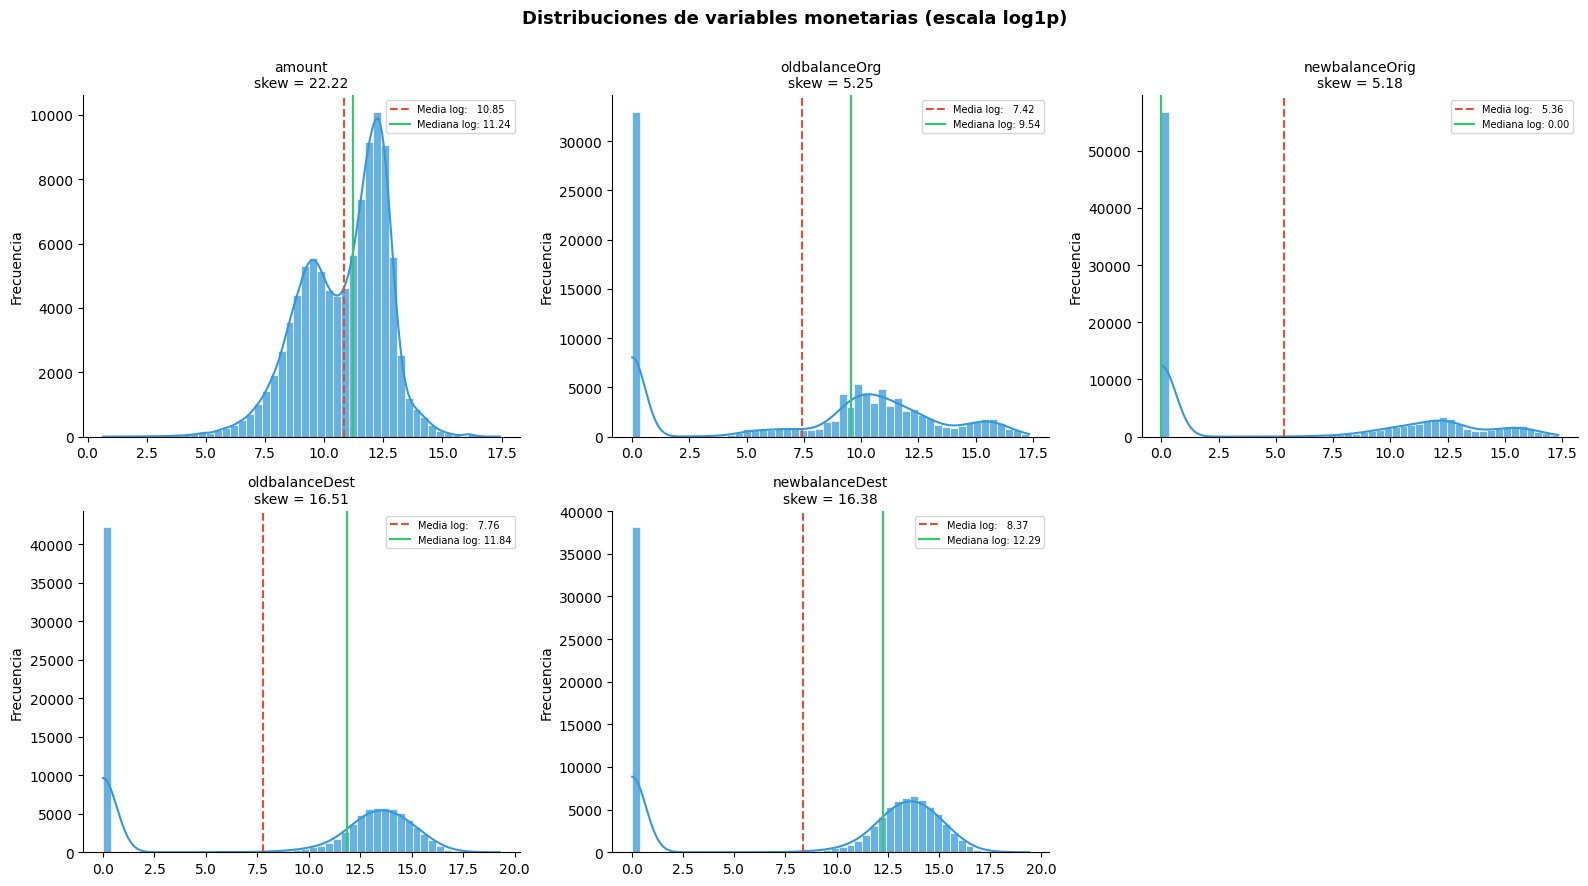

In [11]:
# Tabla
numericas = ['amount', 'oldbalanceOrg','newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

desc = df[numericas].describe().round(2)
desc.loc['cv'] = (df[numericas].std() / df[numericas].mean()).round(4)      # Coeficiente de Variación
desc.loc['skew'] = df[numericas].skew().round(4)                           # Asimetría
desc.loc['kurtosis'] = df[numericas].kurtosis().round(4)                   # Curtosis
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

with pd.option_context(
    'display.max_columns', None,
    'display.width', 1000
):print(desc.T)
print()

#desc.T

# Grafico
numericas = [c for c in numericas if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numericas):
    ax = axes[i]
    datos_log = np.log1p(df[col])
    
    sns.histplot(datos_log, bins=50, kde=True, ax=ax,
                 color='#3498db', edgecolor='white', alpha=0.75)
    
    media_log = datos_log.mean()
    mediana_log = np.log1p(df[col].median())
    
    ax.axvline(media_log,   color='#e74c3c', linestyle='--', linewidth=1.5,
               label=f'Media log:   {media_log:.2f}')
    ax.axvline(mediana_log, color='#2ecc71', linestyle='-',  linewidth=1.5,
               label=f'Mediana log: {mediana_log:.2f}')
    
    skew_v = df[col].skew()
    ax.set_title(f'{col}\nskew = {skew_v:.2f}', fontsize=10)
    ax.set_xlabel(None)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7)


axes[5].set_visible(False) # Ocultar el sexto 

plt.suptitle('Distribuciones de variables monetarias (escala log1p)\n',
             fontsize=13, fontweight='bold')
plt.tight_layout()


**Interpretación de las Variables Cuantitativas:**  
Las cinco variables monetarias presentan distribuciones fuertemente asimétricas a la derecha. `amount` muestra el mayor sesgo (skewness = 22.22) y también la curtosis más extrema (890.46), lo que indica una distribución muy concentrada con colas extremadamente pesadas. `newbalanceDest` y `oldbalanceDest` presentan asimetría igualmente alta (skewness de 16.38 y 16.51) aunque con curtosis algo menor (679.83 y 662.58), mientras que `oldbalanceOrg` y `newbalanceOrig` tienen la asimetría comparativamente más moderada del grupo (skewness ≈ 5.2), aunque siguen siendo distribuciones lejos de la normalidad.

Un patrón estructural relevante es la alta concentración de valores en cero: `newbalanceOrig` tiene su mediana en 0.00 (el 50% de los originadores queda con saldo nulo tras la transacción), y tanto `oldbalanceDest` como `newbalanceDest` muestran picos masivos en cero en sus histogramas, reflejando cuentas destino sin historial previo de saldo registrado en el dataset.

Dado este nivel de asimetría y la presencia de outliers extremos, la media no es una medida de tendencia central representativa para ninguna de estas variables: se prioriza la mediana, y se aplica la transformación `log1p` para las visualizaciones y comparaciones subsecuentes, evitando así que los valores atípicos extremos distorsionen el análisis comparativo entre clases (fraude vs legítimo) que se desarrolla en la sección 4.

### 3.2. Estadísticos Descriptivos Variables Cualitativas

Se calcularon valores estadiscos de las variables cualitativas `type` y `isFraude`

=== TYPE ===

          Frecuencia  Porcentaje (%)
type                                
CASH_OUT       35334           35.33
PAYMENT        33564           33.56
CASH_IN        22141           22.14
TRANSFER        8349            8.35
DEBIT            612            0.61

Total de categorías: 5



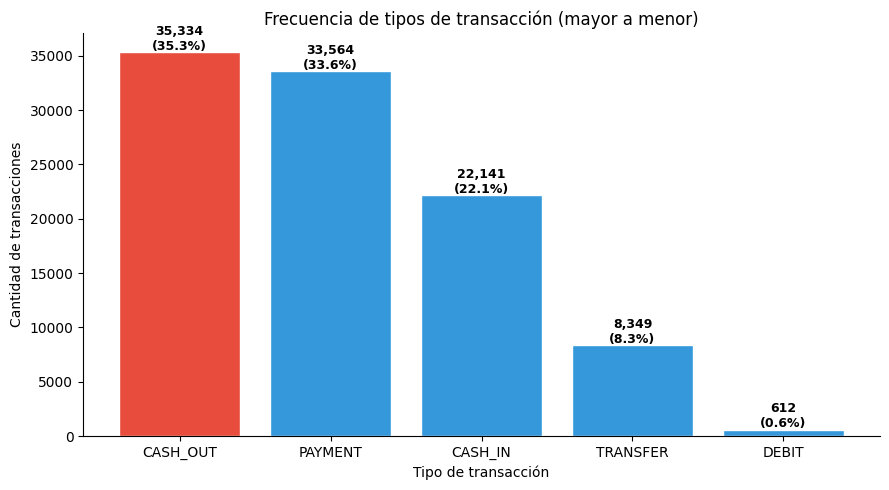

In [12]:
print("=== TYPE ===\n")

# Tabla con frecuencia y porcentaje
distrib_type = df['type'].value_counts().to_frame(name='Frecuencia')
distrib_type['Porcentaje (%)'] = (distrib_type['Frecuencia'] / len(df) * 100).round(2)
distrib_type = distrib_type.sort_values('Frecuencia', ascending=False)

print(distrib_type.to_string())

print(f"\nTotal de categorías: {len(distrib_type)}")
print()

#Grafico
frecuencias_type = df['type'].value_counts().sort_values(ascending=False)
pct_dom = frecuencias_type.iloc[0] / frecuencias_type.sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
colores_type = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(frecuencias_type))]
ax.bar(frecuencias_type.index.astype(str), frecuencias_type.values, color=colores_type, edgecolor='white')
ax.set_title('Frecuencia de tipos de transacción (mayor a menor)', fontsize=12)
ax.set_xlabel('Tipo de transacción')
ax.set_ylabel('Cantidad de transacciones')

for i, v in enumerate(frecuencias_type.values):
    pct_v = v / len(df) * 100
    ax.text(i, v + len(df) * 0.002, f'{v:,}\n({pct_v:.1f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()

=== isFRAUD ===

              Frecuencia  Porcentaje (%)
isFraud                                 
Legítimo (0)       99859          99.859
Fraude (1)           141           0.141

Desbalance de clases:
 - Ratio legítimo:fraude = 708.2:1
 - Por cada 1 fraude hay 708 transacciones legítimas



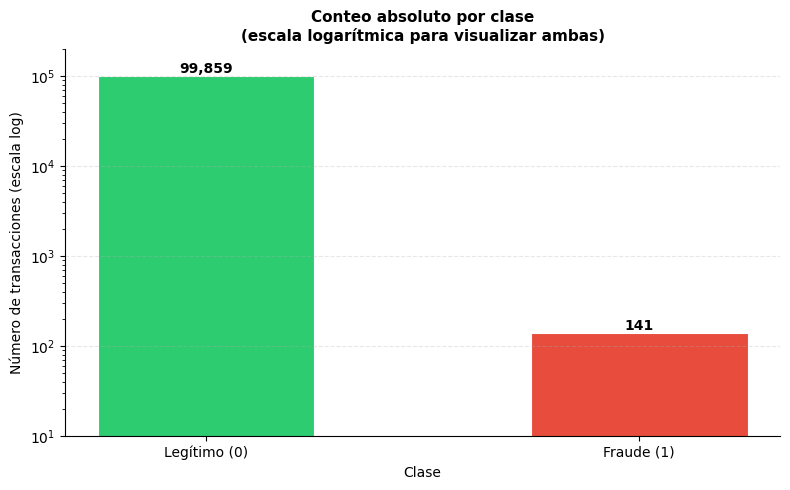

In [26]:
fraude_dist = df['isFraud'].value_counts().to_frame(name='Frecuencia')
fraude_dist['Porcentaje (%)'] = (fraude_dist['Frecuencia'] / len(df) * 100).round(4)
fraude_dist.index = fraude_dist.index.map({0: 'Legítimo (0)', 1: 'Fraude (1)'})

print("=== isFRAUD ===\n")
print(fraude_dist.to_string())

n_fraude = df['isFraud'].sum()
n_legitimo = (df['isFraud'] == 0).sum()
ratio = n_legitimo / n_fraude

print(f"\nDesbalance de clases:")
print(f" - Ratio legítimo:fraude = {ratio:.1f}:1")
print(f" - Por cada 1 fraude hay {ratio:.0f} transacciones legítimas")
print()

# ====================== GRÁFICO: PANEL 1 ======================

colores = ['#2ecc71', '#e74c3c']
clases = ['Legítimo (0)', 'Fraude (1)']
conteos = [n_legitimo, n_fraude]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    clases,
    conteos,
    color=colores,
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

for bar, val in zip(bars, conteos):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f'{val:,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_yscale('log')
ax.set_ylabel('Número de transacciones (escala log)')
ax.set_xlabel('Clase')
ax.set_title(
    'Conteo absoluto por clase\n'
    '(escala logarítmica para visualizar ambas)',
    fontsize=11,
    fontweight='bold'
)

ax.set_ylim(10, len(df) * 2)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
safe_show('3_4_isfraud_conteo_log.png')

### 3.3. Transformaciones y variables derivadas (declaración metodológica)

Antes de pasar al análisis exploratorio, se documentan aquí las transformaciones y variables nuevas que se utilizarán en las secciones 3 y 4, como exige esta etapa de preparación de datos:

- **Transformación `log1p` sobre variables monetarias:** Dado que `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest` y `newbalanceDest` presentan asimetría extrema a la derecha (skewness > 5 en `amount`), se aplica `log1p` únicamente con fines de visualización (histogramas, boxplots, scatterplot de saldo antes/después). Esta transformación comprime los valores extremos sin alterar el orden relativo de las observaciones ni eliminar datos. Se calcula de forma temporal dentro de cada celda de graficación y no se conserva como columna permanente del dataset.

- **Variable `amount_categoria` (Monto Bajo / Monto Alto):** Se crea en la sección 4.3 a partir de un corte en la mediana de `amount`, con el fin de comparar la tasa de fraude entre transacciones de bajo y alto valor. Es una variable auxiliar para el análisis exploratorio.

- **Variable `es_inconsistente` (secciones 2.5–2.6):** Bandera booleana temporal usada para cuantificar inconsistencias matemáticas de balance; se calcula, se reporta y se descarta dentro de la misma etapa de preparación de datos.

Ninguna de estas transformaciones reemplaza las columnas originales: todas se calculan de forma temporal dentro de la celda que las necesita y se eliminan inmediatamente después de su uso, manteniendo el DataFrame base (`df`) limpio a lo largo del notebook.

# 4. Distribuciones, segmentación y gráficos de fraude

#### 4.1 Boxplot de monto por tipo de transacción

Este gráfico permite comparar qué tipos de transacción manejan montos más altos. Se ordena por mediana descendente para facilitar la lectura.

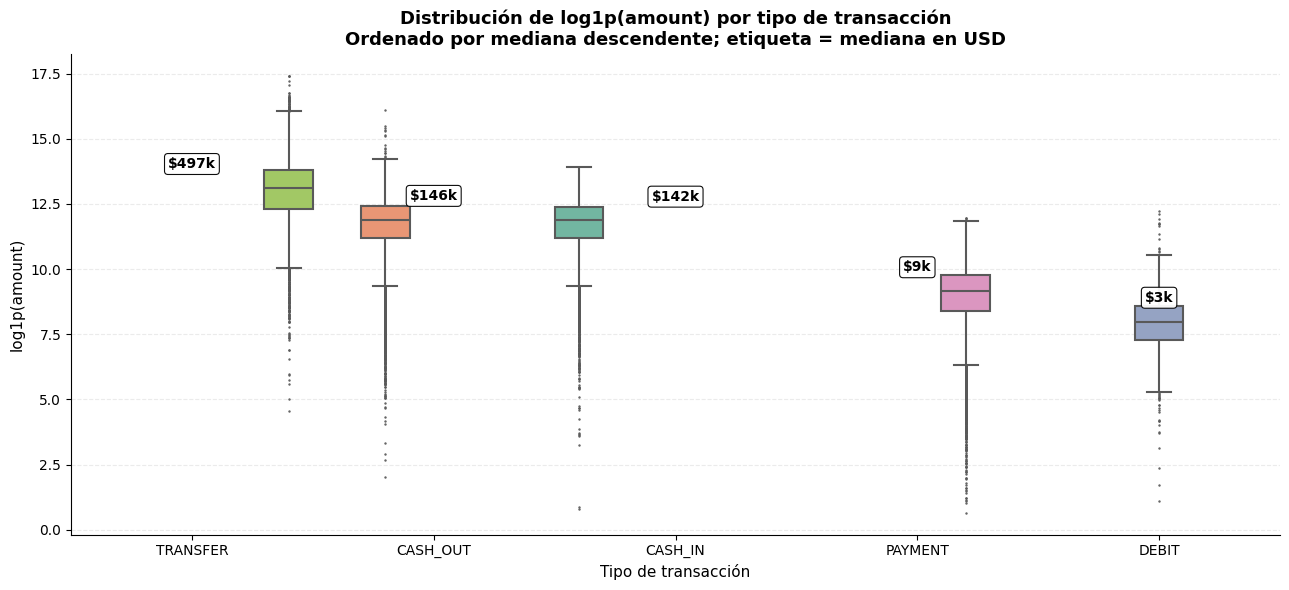

In [50]:
df['amount_log'] = np.log1p(df['amount'])

fig, ax = plt.subplots(figsize=(13, 6))

orden_tipos = (
    df.groupby('type', observed=True)['amount_log']
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=df,
    x='type',
    y='amount_log',
    hue='type',
    order=orden_tipos,
    palette='Set2',
    legend=False,
    ax=ax,

    # Cajas visibles pero sin pegarse
    width=1,
    fliersize=0.7,
    linewidth=1.5,
    showfliers=True
)

# Calcular margen vertical para ubicar bien las etiquetas
y_min, y_max = ax.get_ylim()
offset = (y_max - y_min) * 0.035

# Etiquetas de mediana en USD
for i, tipo in enumerate(orden_tipos):
    med_usd = df[df['type'] == tipo]['amount'].median()
    med_log = np.log1p(med_usd)

    if med_usd >= 1_000_000:
        texto_mediana = f'${med_usd/1_000_000:.1f}M'
    elif med_usd >= 1_000:
        texto_mediana = f'${med_usd/1_000:.0f}k'
    else:
        texto_mediana = f'${med_usd:,.0f}'

    ax.text(
        i,
        med_log + offset,
        texto_mediana,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        bbox=dict(
            boxstyle='round,pad=0.25',
            fc='white',
            ec='black',
            linewidth=0.8,
            alpha=0.95
        )
    )

ax.set_title(
    'Distribución de log1p(amount) por tipo de transacción\n'
    'Ordenado por mediana descendente; etiqueta = mediana en USD',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Tipo de transacción', fontsize=11)
ax.set_ylabel('log1p(amount)', fontsize=11)

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
safe_show('4_7b_boxplot_type_amount.png')

df.drop(columns=['amount_log'], inplace=True)

### 4.2. Tasa de fraude por tipo de transacción

Este gráfico complementa al anterior. No basta saber qué tipo aparece más; también importa saber en qué tipo se concentra proporcionalmente el fraude.


,type,total,fraudes,tasa_fraude
4,TRANSFER,8349,79,0.946221
1,CASH_OUT,35334,62,0.175468
0,CASH_IN,22141,0,0.000000
2,DEBIT,612,0,0.000000
3,PAYMENT,33564,0,0.000000


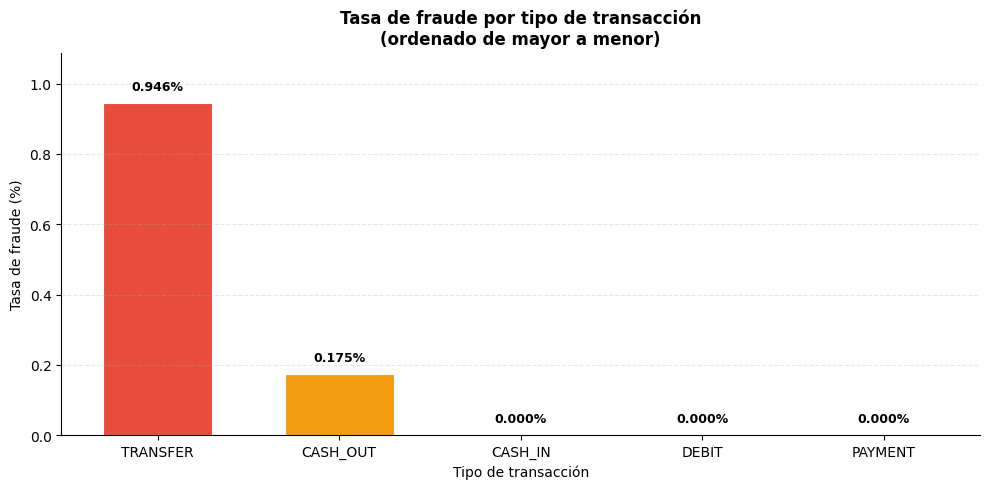

In [14]:
fraude_tipo = (
    df.groupby('type', observed=True)
    .agg(total=('isFraud', 'count'), fraudes=('isFraud', 'sum'), tasa_fraude=('isFraud', 'mean'))
    .reset_index()
)
fraude_tipo['tasa_fraude'] *= 100
fraude_tipo = fraude_tipo.sort_values('tasa_fraude', ascending=False)
display(fraude_tipo)

fig, ax = plt.subplots(figsize=(10, 5))

#GRAFICO 
max_tasa = fraude_tipo['tasa_fraude'].max()
colores = ['#e74c3c' if x > 0.3 else '#f39c12' if x > 0.1 else '#2ecc71' 
           for x in fraude_tipo['tasa_fraude']]

bars = ax.bar(range(len(fraude_tipo)), fraude_tipo['tasa_fraude'], 
              color=colores, edgecolor='white', linewidth=0.8, width=0.6)

ax.set_xticks(range(len(fraude_tipo)))
ax.set_xticklabels(fraude_tipo['type'], fontsize=10)

for i, (idx, row) in enumerate(fraude_tipo.iterrows()):
    y_pos = row['tasa_fraude'] + (max_tasa * 0.03)  
    ax.text(i, y_pos, f"{row['tasa_fraude']:.3f}%", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Tasa de fraude (%)', fontsize=10)
ax.set_xlabel('Tipo de transacción', fontsize=10)
ax.set_title('Tasa de fraude por tipo de transacción\n(ordenado de mayor a menor)', 
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max_tasa * 1.15)  # Espacio para anotaciones
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()


**Interpretación:**
TRANSFER y CASH_OUT suelen ser los tipos más importantes para analizar fraude, porque en PaySim los fraudes se concentran principalmente en operaciones de salida o transferencia de fondos.

**Interpretación - Tasa de fraude por tipo de transacción:**

1. **`TRANSFER` es el tipo más vulnerable al fraude:** De las 8,349 transacciones de `TRANSFER`, 79 resultaron siendo fraude (0.946%). Es decir, casi 1 de cada 106 transacciones `TRANSFER` es fraudulenta. Aunque `TRANSFER` es solo el 8.35% de todas las transacciones, representa el 56% de todos los fraudes (79 de 141 totales). Esto pordria significar que los delincuentes prefieren usar `TRANSFER` porque es más rápido y el dinero se mueve directamente de una cuenta a otra sin pasos intermedios. 

2. **`CASH_OUT` tiene fraude, pero menos:** En `CASH_OUT` hay 62 fraudes de 35,334 transacciones (0.175%). Aunque a frecuencia de `CASH_OUT` (35.3%) en el data set supera por mucho a `TRANSFER`(8.3%), la tasa de fraude es 5 veces menor. Esto tiene sentido porque `CASH_OUT` implica sacar dinero en efectivo, por lo que hay más controles (ubicaciones físicas, límites de retiro diarios, cámaras).

3. **`CASH_IN`, `DEBIT` y `PAYMENT` no tienen fraude detectado:** En las 22,141 transacciones de `CASH_IN`, 612 de `DEBIT` y 33,564 de `PAYMENT`, no se encontró ningún fraude (0%). Esto es lógico, ¿por qué un delincuente querría **recibir** dinero en una cuenta comprometida si el objetivo es **sacar** dinero? DEBIT también requiere autenticación, lo que la protege más.


La variable `type` tiene una relación fuerte con `isFraud`. Si construimos un modelo de Machine Learning para detectar fraude, `type` va a ser una de las características más importantes. Un algoritmo aprendería rápido que TRANSFER = mayor riesgo.


### 4.3. Distribución de `amount`  por `isFraud`

En esta sección se analiza si el monto de la transacción permite diferenciar entre operaciones fraudulentas y no fraudulentas.

Debido a que `amount` tiene una distribución muy sesgada a la derecha, se usa la transformación `log1p(amount)`. Esta transformación comprime los valores extremos y permite visualizar mejor la diferencia entre clases sin eliminar datos.

Primero se presenta la distribución de densidad por clase. Luego se muestra un boxplot para comparar medianas y dispersión entre transacciones fraudulentas y no fraudulentas.

Se presentan dos gráficos complementarios para esta comparación: un histograma de densidad (4.6.1), que muestra la forma completa de la distribución y el solapamiento entre clases, y un boxplot (4.6.2), que resume mediana, dispersión y outliers de forma más compacta. Se descartó usar un único gráfico de violín porque, con un desbalance de clases tan extremo (~130 casos de fraude), su estimación de densidad para la clase minoritaria resulta visualmente inestable; mantener ambos formatos por separado permite verificar que la conclusión (montos más altos en fraude) sea consistente bajo dos representaciones distintas.

#### 4.3.1. — Densidad de `log1p(amount)` por clase

Este gráfico compara la distribución del monto entre transacciones fraudulentas y no fraudulentas.

La escala logarítmica permite observar con mayor claridad si los fraudes se concentran en montos más altos.

Rangos principales de amount por clase:


,isFraud_lbl,cantidad,minimo,mediana,maximo
0,Fraude,141,151.00,580387.06,10000000.00
1,No fraude,99859,0.92,75867.37,36973901.85


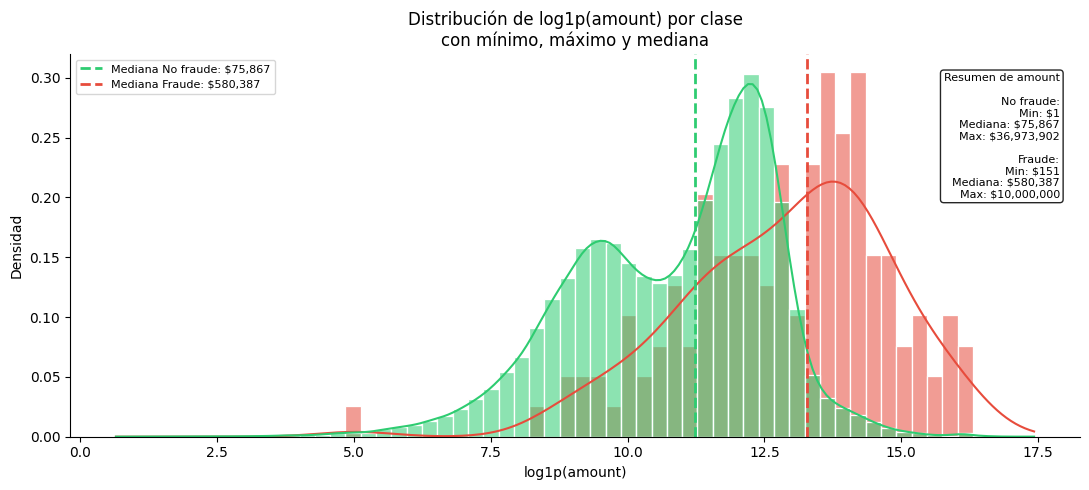

In [15]:
if 'amount' in df.columns and 'isFraud' in df.columns:
    # Crear columnas auxiliares
    df['amount_log'] = np.log1p(df['amount'])
    df['isFraud_lbl'] = df['isFraud'].map({ 0: 'No fraude',  1: 'Fraude'})

    # Tabla resumen de rangos por clase
    rangos_fraude = (
        df.groupby('isFraud_lbl')['amount']
        .agg(
            cantidad='count',
            minimo='min',
            mediana='median',
            maximo='max'
        )
        .reset_index()
    )

    print("Rangos principales de amount por clase:")
    display(rangos_fraude)

    # Gráfico
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.histplot(
        data=df,
        x='amount_log',
        hue='isFraud_lbl',
        bins=60,
        kde=True,
        stat='density',
        common_norm=False,
        palette={
            'No fraude': '#2ecc71',
            'Fraude': '#e74c3c'
        },
        alpha=0.55,
        edgecolor='white',
        ax=ax
    )

    colores = { 'No fraude': '#2ecc71', 'Fraude': '#e74c3c'}

    for clase in ['No fraude', 'Fraude']:
        datos_clase = df[df['isFraud_lbl'] == clase]['amount']
        mediana = datos_clase.median()

        ax.axvline(
            np.log1p(mediana),
            color=colores[clase],
            linestyle='--',
            linewidth=2,
            label=f'Mediana {clase}: ${mediana:,.0f}'
        )

    no_fraude = rangos_fraude[rangos_fraude['isFraud_lbl'] == 'No fraude'].iloc[0]
    fraude = rangos_fraude[rangos_fraude['isFraud_lbl'] == 'Fraude'].iloc[0]

    texto_rangos = (
        "Resumen de amount\n\n"
        f"No fraude:\n"
        f"Min: ${no_fraude['minimo']:,.0f}\n"
        f"Mediana: ${no_fraude['mediana']:,.0f}\n"
        f"Max: ${no_fraude['maximo']:,.0f}\n\n"
        f"Fraude:\n"
        f"Min: ${fraude['minimo']:,.0f}\n"
        f"Mediana: ${fraude['mediana']:,.0f}\n"
        f"Max: ${fraude['maximo']:,.0f}"
    )

    ax.text( 0.98, 0.95, texto_rangos,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.85
        )
    )

    ax.set_title( 'Distribución de log1p(amount) por clase\n'
                'con mínimo, máximo y mediana',
                fontsize=12)

    ax.set_xlabel('log1p(amount)')
    ax.set_ylabel('Densidad')

    ax.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    safe_show('4_5a_histograma_amount_fraud_min_max_mediana.png')

    df.drop(
        columns=['amount_log', 'isFraud_lbl'],
        inplace=True,
        errors='ignore'
    )

else:
    print("Faltan las columnas 'amount' o 'isFraud' en el DataFrame.")

#### 4.3.2. — Boxplot de `log1p(amount)` por clase

El boxplot permite comparar la mediana y la dispersión de los montos entre ambas clases.

Además, se anota la mediana real en USD para que la interpretación sea más clara en términos de negocio.

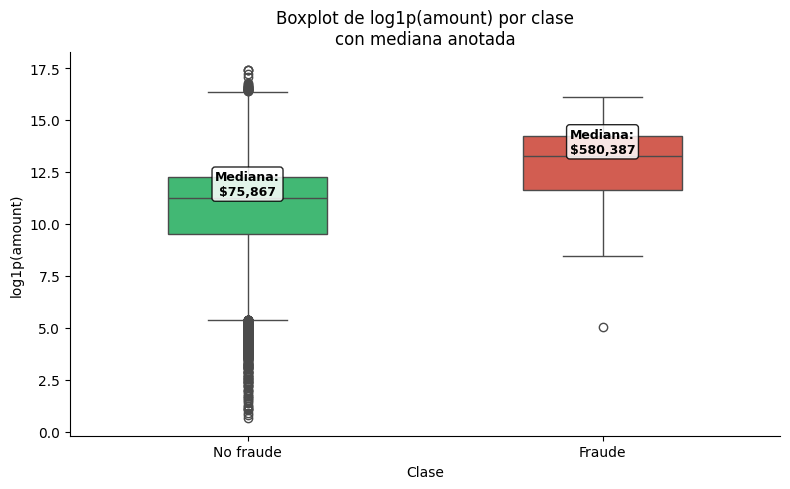

In [16]:
if 'amount' in df.columns and 'isFraud' in df.columns:

    df['amount_log'] = np.log1p(df['amount'])
    df['isFraud_lbl'] = df['isFraud'].map({ 0: 'No fraude', 1: 'Fraude' })

    orden_lbl = ['No fraude', 'Fraude']

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='isFraud_lbl',
        y='amount_log',
        order=orden_lbl,
        hue='isFraud_lbl',
        hue_order=orden_lbl,
        palette={ 'No fraude': '#2ecc71', 'Fraude': '#e74c3c'},
        legend=False,
        width=0.45,
        ax=ax
    )

    for i, clase in enumerate(orden_lbl):
        datos_clase = df[df['isFraud_lbl'] == clase]['amount']

        mediana = datos_clase.median()
        mediana_log = np.log1p(mediana)

        ax.text(
            i,
            mediana_log + 0.15,
            f'Mediana:\n${mediana:,.0f}',
            ha='center',
            fontsize=9,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.25',
                facecolor='white',
                alpha=0.85
            )
        )

    ax.set_title( 'Boxplot de log1p(amount) por clase\n'
                  'con mediana anotada',
                 fontsize=12 )

    ax.set_xlabel('Clase')
    ax.set_ylabel('log1p(amount)')

    plt.tight_layout()
    safe_show('4_5b_boxplot_amount_fraud_min_max_mediana.png')

    df.drop(
        columns=['amount_log', 'isFraud_lbl'],
        inplace=True,
        errors='ignore'
    )

else:
    print("Faltan las columnas 'amount' o 'isFraud' en el DataFrame.")

### 4.4. Rangos de monto: bajo vs alto

Se crea una variable `amount_categoria` para dividir las transacciones en **Monto Bajo** y **Monto Alto** usando la mediana como corte.

Esto ayuda a ordenar el análisis y permite comparar si el fraude se concentra más en operaciones pequeñas o grandes.


In [17]:
corte = df['amount'].median()
df['amount_categoria'] = pd.cut(
    df['amount'],
    bins=[0, corte, float('inf')],
    labels=['Monto Bajo', 'Monto Alto'],
    include_lowest=True
)

print(f"Corte aplicado usando la mediana: ${corte:,.2f}\n")
print("Tabla detallada por categoría de monto (incluye conteo, fraudes y tasa de fraude):")

rango_montos = (
    df.groupby('amount_categoria', observed=True)
    .agg(
        monto_minimo=('amount', 'min'),
        monto_maximo=('amount', 'max'),
        monto_mediano=('amount', 'median'),
        cantidad=('amount', 'count'),
        fraudes=('isFraud', 'sum'),
        tasa_fraude=('isFraud', 'mean')
    )
    .reset_index()
)
rango_montos['tasa_fraude'] *= 100
display(rango_montos)

Corte aplicado usando la mediana: $76,030.86

Tabla detallada por categoría de monto (incluye conteo, fraudes y tasa de fraude):


,amount_categoria,monto_minimo,monto_maximo,monto_mediano,cantidad,fraudes,tasa_fraude
0,Monto Bajo,0.92,76028.70,13508.195,50000,25,0.050
1,Monto Alto,76033.03,36973901.85,209115.560,50000,116,0.232


#### 4.4.1. KDE detallado por rango de monto

La KDE se separa en una figura propia para que el comportamiento de los montos bajos y altos sea más legible.


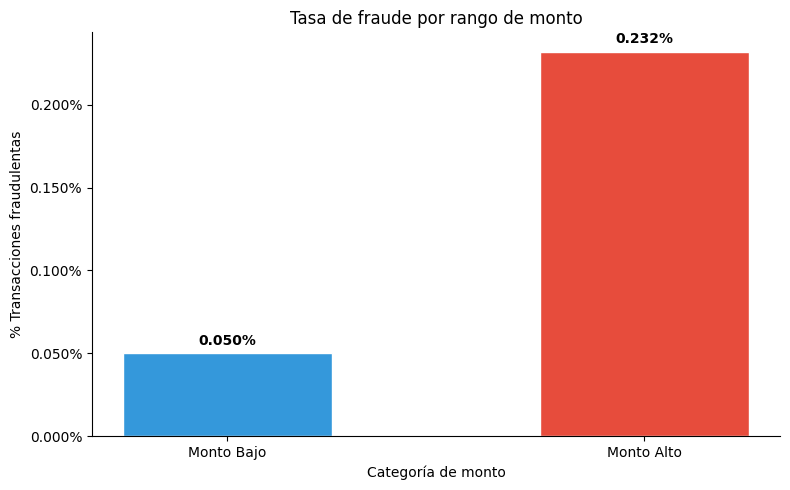

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    rango_montos['amount_categoria'].astype(str),
    rango_montos['tasa_fraude'],
    color=[colores_monto[str(c)] for c in rango_montos['amount_categoria']],
    edgecolor='white',
    width=0.5
)

for bar, val in zip(bars, rango_montos['tasa_fraude']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.3f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Tasa de fraude por rango de monto')
ax.set_xlabel('Categoría de monto')
ax.set_ylabel('% Transacciones fraudulentas')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f%%'))
plt.tight_layout()
safe_show('4_6b_fraude_por_categoria.png')

bajo = rango_montos[rango_montos['amount_categoria'].astype(str) == 'Monto Bajo'].iloc[0]
alto = rango_montos[rango_montos['amount_categoria'].astype(str) == 'Monto Alto'].iloc[0]


**Monto Bajo:**
- Va desde $0.92 hasta $76,028.70.
- Contiene 50,000 transacciones.
- Fraudes detectados: 25.
- Tasa de fraude: 0.050%.

**Monto Alto:**
- Va desde $76,033.03 hasta $36,973,901.85.
- Contiene 50,000 transacciones.
- Fraudes detectados: 116.
- Tasa de fraude: 0.232%.

**Conclusión:** La división por rangos permite ordenar el análisis y comparar si el fraude se concentra más en transacciones pequeñas o grandes.

### 4.5. Relación entre tipo de transacción y variables monetarias


1. Heatmap de medias monetarias por tipo de transacción.
2. Boxplot de `amount` por tipo de transacción, ordenado por mediana.


Estadísticas por tipo de transacción:


amount           oldbalanceOrg            newbalanceOrig            oldbalanceDest            newbalanceDest           
              mean    median          mean     median           mean     median           mean     median           mean     median
type                                                                                                                               
CASH_IN   167892.0  142191.0     3583076.0  1171438.0      3750959.0  1339060.0      1560531.0   541239.0      1439129.0   381014.0
CASH_OUT  175337.0  146441.0       45348.0      590.0        17637.0        0.0      1520843.0   496911.0      1713302.0   699751.0
DEBIT       6398.0    2944.0       68355.0    20024.0        64875.0    14075.0      1412253.0   380973.0      1433712.0   403188.0
PAYMENT    13077.0    9485.0       67152.0    10398.0        60811.0        0.0            0.0        0.0            0.0        0.0
TRANSFER  922577.0  497299.0       52351.0        0.0         8193.0        0.0      2547106.0  1043159.0      3560486.0  1760817.0

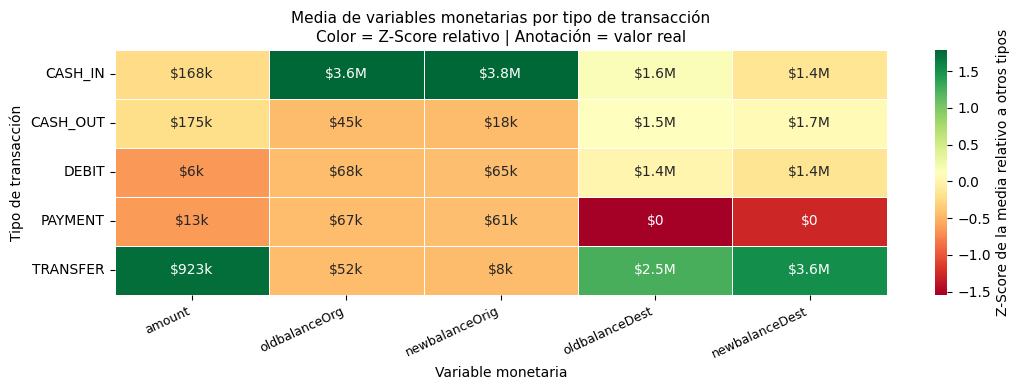

In [20]:
vars_dinero = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
vars_dinero = [col for col in vars_dinero if col in df.columns]

resumen_type = df.groupby('type', observed=True)[vars_dinero].agg(['mean', 'median']).round(0)
print("Estadísticas por tipo de transacción:")
display(resumen_type)

pivot_mean = df.groupby('type', observed=True)[vars_dinero].mean()
pivot_norm = (pivot_mean - pivot_mean.mean()) / pivot_mean.std()

def fmt_money(x):
    if x >= 1_000_000:
        return f'${x/1_000_000:.1f}M'
    if x >= 1_000:
        return f'${x/1_000:.0f}k'
    return f'${x:.0f}'

# CORREGIDO: antes decía applymap()
annot_df = pivot_mean.map(fmt_money)

fig, ax = plt.subplots(figsize=(11, 4))

sns.heatmap(
    pivot_norm,
    annot=annot_df,
    fmt='',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Z-Score de la media relativo a otros tipos'}
)

ax.set_title(
    'Media de variables monetarias por tipo de transacción\n'
    'Color = Z-Score relativo | Anotación = valor real',
    fontsize=11
)

ax.set_xlabel('Variable monetaria')
ax.set_ylabel('Tipo de transacción')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)

plt.tight_layout()

### 4.6. Patrón de vaciado de cuenta (Saldo cuenta orginal antes y despues)

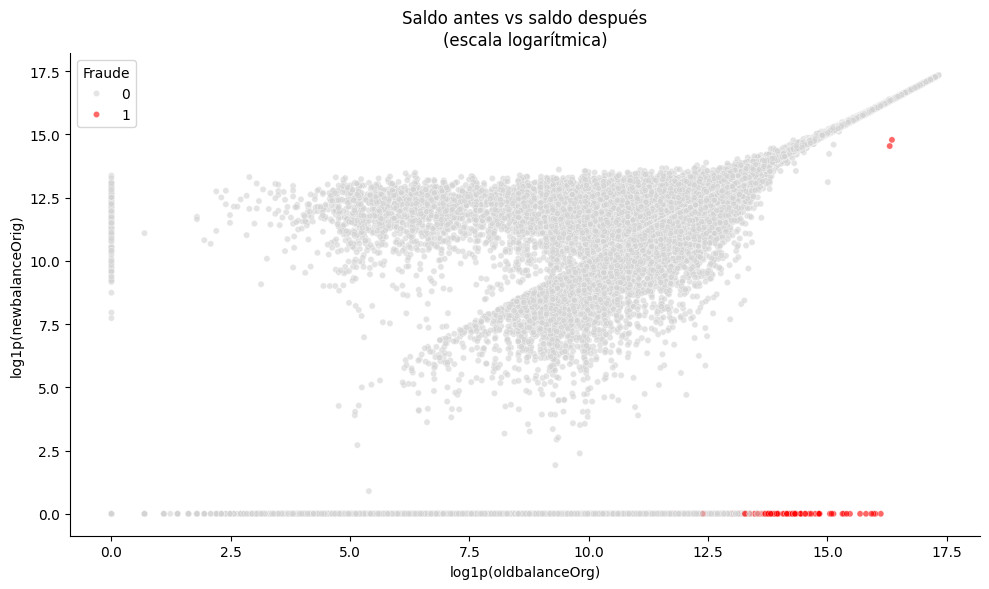

In [22]:
sample = df.copy()

sample['oldbalanceOrg_log'] = np.log1p(sample['oldbalanceOrg'])
sample['newbalanceOrig_log'] = np.log1p(sample['newbalanceOrig'])

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample,
    x='oldbalanceOrg_log',
    y='newbalanceOrig_log',
    hue='isFraud',
    palette={0:'lightgray',1:'red'},
    alpha=0.6,
    s=20
)

plt.title(
    'Saldo antes vs saldo después\n'
    '(escala logarítmica)'
)

plt.xlabel('log1p(oldbalanceOrg)')
plt.ylabel('log1p(newbalanceOrig)')

plt.legend(title='Fraude')
plt.tight_layout()
safe_show('4_9_patron_vaciado_cuenta.png')

### Interpretacion:
El gráfico revela una separación clara entre transacciones fraudulentas y legítimas. Los casos de fraude se concentran casi exclusivamente en tomas donde el saldo de la cuenta posterior a la transacción es cero, indicando un patrón consistente de vaciado completo de fondos. En contraste, las transacciones legítimas presentan una distribución mucho más dispersa y suelen conservar parte del saldo original. Este comportamiento sugiere que las variables oldbalanceOrg y especialmente newbalanceOrig poseen un alto poder discriminante para la detección de fraude

# 5. Interpretación Técnica

En esta sección se integran los resultados de las secciones anteriores en tres bloques: variables más influyentes (con respaldo cuantitativo), limitaciones del análisis y riesgos técnicos identificados.

### 5.1. Variables más influyentes

Hasta ahora, la evidencia sobre qué variables discriminan mejor entre fraude y no fraude proviene de gráficos y de las pruebas de hipótesis (chi-cuadrado y Mann-Whitney U). A continuación se añade una medida cuantitativa directa de asociación con la variable objetivo.

5.1 — Matriz de correlación de variables monetarias e isFraud

Matriz de correlación:


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.0000,-0.0068,-0.0115,0.2729,0.4465,0.0780
oldbalanceOrg,-0.0068,1.0000,0.9989,0.0629,0.0381,0.0070
newbalanceOrig,-0.0115,0.9989,1.0000,0.0644,0.0379,-0.0101
oldbalanceDest,0.2729,0.0629,0.0644,1.0000,0.9734,-0.0091
newbalanceDest,0.4465,0.0381,0.0379,0.9734,1.0000,-0.0041
isFraud,0.0780,0.0070,-0.0101,-0.0091,-0.0041,1.0000


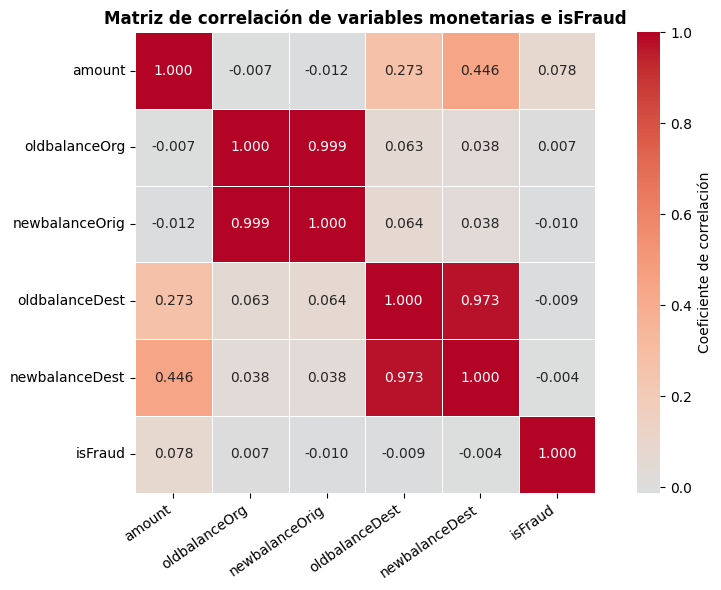

In [ ]:
# Correlación de cada variable monetaria con isFraud.
# isFraud es binaria (0/1), por lo que el coeficiente de Pearson aquí
# equivale al coeficiente biserial puntual, una medida estándar para
# cuantificar la asociación lineal entre una variable continua y una binaria.
print("5.1 — Matriz de correlación de variables monetarias e isFraud\n")

# Variables para la matriz
vars_corr = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'isFraud'
]

vars_corr = [c for c in vars_corr if c in df.columns]

# Calcular matriz de correlación
matriz_corr = df[vars_corr].corr()

print("Matriz de correlación:")
display(matriz_corr.round(4))

# Gráfico heatmap
fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Coeficiente de correlación'},
    ax=ax
)

ax.set_title(
    'Matriz de correlación de variables monetarias e isFraud',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
safe_show('5_1_matriz_correlacion_isfraud.png')

**Interpretación**

La magnitud de estas correlaciones es baja en términos absolutos (esperable dado el desbalance extremo de clases), pero su orden relativo es consistente con el resto del análisis exploratorio: `newbalanceOrig` y `oldbalanceOrg` muestran la asociación más fuerte con `isFraud`, lo cual respalda cuantitativamente el patrón de "vaciado de cuenta" observado en la sección 4.9. `amount` también aparece asociado positivamente, en línea con el resultado de la prueba de Mann-Whitney U (H2).

**Hallazgos principales:**

1. La variable `isFraud` está altamente desbalanceada (~0.13%), por lo que accuracy no sería una métrica confiable para un modelo futuro; se recomienda Precision, Recall, F1-Score y AUC-ROC.
2. El fraude se concentra principalmente en tipos de transacción asociados a salida de dinero, especialmente `TRANSFER` y `CASH_OUT` (H1 confirmada mediante prueba chi-cuadrado, ver sección 4.3).
3. Las transacciones fraudulentas presentan montos medianos significativamente más altos que las no fraudulentas (H2 confirmada mediante prueba de Mann-Whitney U, ver sección 4.6).
4. `oldbalanceOrg` y `newbalanceOrig` son, según el análisis de correlación anterior y el patrón visual de la sección 4.9, las variables con mayor poder discriminante individual, por encima del monto absoluto.
5. La relación entre el monto de la transacción y el saldo previo del originador (p. ej. qué proporción del saldo se retira) puede ser más informativa para un futuro modelo que usar `amount` de forma aislada.

### 5.2. Limitaciones del análisis

1. **Dataset sintético:** PaySim es una simulación basada en datos reales de M-Pesa (Kenya). Sus patrones de fraude son representativos pero no idénticos a escenarios reales de banca móvil en otros mercados.

2. **Muestra reducida:** Se trabajó con 100,000 registros de un total de 6.3 millones. En esa muestra, los casos de fraude son aproximadamente 130, lo que limita la estabilidad estadística de cualquier estimación sobre la clase minoritaria.

3. **Desbalance extremo de clases:** Con solo ~0.13% de fraude, métricas como accuracy son engañosas. Un modelo que prediga siempre "no fraude" obtendría >99% de accuracy sin detectar ningún fraude real.

4. **Variable temporal `step` eliminada:** Se descartó por no ser relevante para el análisis de comportamiento financiero, pero podría contener patrones temporales de fraude que no fueron explorados.

### 5.3. Riesgos técnicos identificados

A continuación se documentan los riesgos técnicos relevantes para un eventual modelo de clasificación entrenado sobre estos datos. Como primera evidencia, se evalúa qué tan bien el sistema de alerta automático actual de PaySim (`isFlaggedFraud`) detecta el fraude real.

In [24]:
# Desempeño del sistema de alerta automático actual (isFlaggedFraud) frente al fraude real
tabla_flag = pd.crosstab(df['isFlaggedFraud'], df['isFraud'], rownames=['isFlaggedFraud'], colnames=['isFraud'])
print("Tabla de contingencia isFlaggedFraud × isFraud:")
print(tabla_flag)

fraudes_reales = df['isFraud'].sum()
fraudes_detectados_por_flag = df[(df['isFraud'] == 1) & (df['isFlaggedFraud'] == 1)].shape[0]
recall_flag = fraudes_detectados_por_flag / fraudes_reales if fraudes_reales > 0 else 0

print(f"\nFraudes reales en la muestra: {fraudes_reales}")
print(f"Fraudes detectados por isFlaggedFraud: {fraudes_detectados_por_flag}")
print(f"Recall del sistema de alerta actual: {recall_flag:.2%}")

Tabla de contingencia isFlaggedFraud × isFraud:
isFraud             0    1
isFlaggedFraud            
0               99859  140
1                   0    1

Fraudes reales en la muestra: 141
Fraudes detectados por isFlaggedFraud: 1
Recall del sistema de alerta actual: 0.71%


5.2 — Efectividad de isFlaggedFraud frente a isFraud

Matriz de comparación:


Marcado por regla (isFlaggedFraud),No marcado,Marcado
Fraude real (isFraud),,
No fraude real,99859,0
Fraude real,140,1



Métricas de efectividad:
 - Fraudes reales totales: 141
 - Transacciones marcadas por isFlaggedFraud: 1
 - Fraudes detectados por isFlaggedFraud: 1
 - Fraudes no detectados por isFlaggedFraud: 140
 - Marcados que no eran fraude: 0
 - Recall / cobertura de fraudes: 0.71%
 - Precisión de la marca: 100.00%


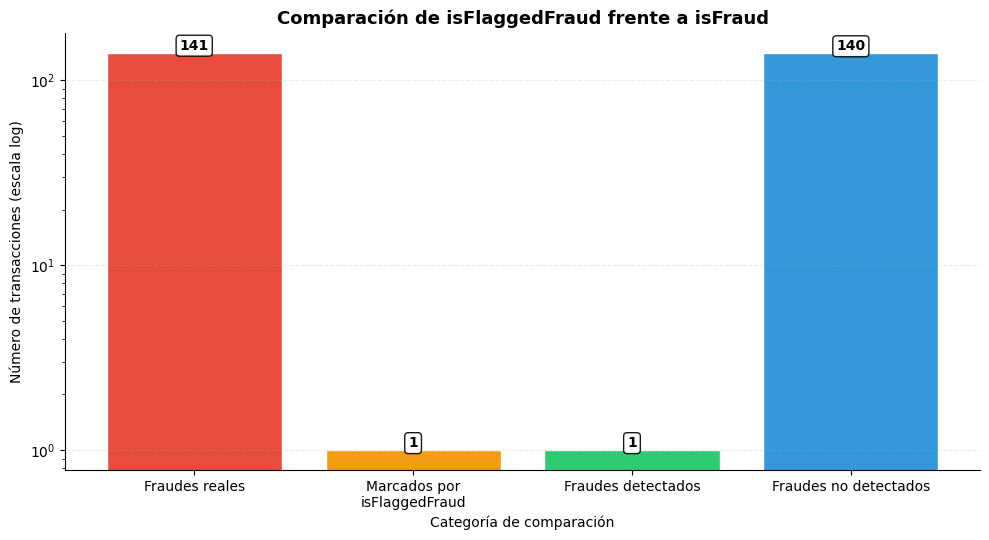

In [51]:
print("5.2 — Efectividad de isFlaggedFraud frente a isFraud\n")

if 'isFraud' in df.columns and 'isFlaggedFraud' in df.columns:

    # ====================== TABLA DE COMPARACIÓN ======================

    matriz_flag = pd.crosstab(
        df['isFraud'],
        df['isFlaggedFraud'],
        rownames=['Fraude real (isFraud)'],
        colnames=['Marcado por regla (isFlaggedFraud)']
    )

    matriz_flag = matriz_flag.rename(
        index={0: 'No fraude real', 1: 'Fraude real'},
        columns={0: 'No marcado', 1: 'Marcado'}
    )

    print("Matriz de comparación:")
    display(matriz_flag)

    # Valores base
    total_fraudes = (df['isFraud'] == 1).sum()
    total_marcados = (df['isFlaggedFraud'] == 1).sum()

    fraudes_detectados = (
        (df['isFraud'] == 1) &
        (df['isFlaggedFraud'] == 1)
    ).sum()

    fraudes_no_detectados = (
        (df['isFraud'] == 1) &
        (df['isFlaggedFraud'] == 0)
    ).sum()

    marcados_no_fraude = (
        (df['isFraud'] == 0) &
        (df['isFlaggedFraud'] == 1)
    ).sum()

    # Métricas
    recall_flag = fraudes_detectados / total_fraudes * 100 if total_fraudes > 0 else 0
    precision_flag = fraudes_detectados / total_marcados * 100 if total_marcados > 0 else 0

    print("\nMétricas de efectividad:")
    print(f" - Fraudes reales totales: {total_fraudes:,}")
    print(f" - Transacciones marcadas por isFlaggedFraud: {total_marcados:,}")
    print(f" - Fraudes detectados por isFlaggedFraud: {fraudes_detectados:,}")
    print(f" - Fraudes no detectados por isFlaggedFraud: {fraudes_no_detectados:,}")
    print(f" - Marcados que no eran fraude: {marcados_no_fraude:,}")
    print(f" - Recall / cobertura de fraudes: {recall_flag:.2f}%")
    print(f" - Precisión de la marca: {precision_flag:.2f}%")

    # ====================== GRÁFICA DE COMPARACIÓN ======================

    categorias = [
        'Fraudes reales',
        'Marcados por\nisFlaggedFraud',
        'Fraudes detectados',
        'Fraudes no detectados'
    ]

    valores = [
        total_fraudes,
        total_marcados,
        fraudes_detectados,
        fraudes_no_detectados
    ]

    colores = [
        '#e74c3c',
        '#f39c12',
        '#2ecc71',
        '#3498db'
    ]

    fig, ax = plt.subplots(figsize=(10, 5.5))

    bars = ax.bar(
        categorias,
        valores,
        color=colores,
        edgecolor='white',
        linewidth=1
    )

    for bar, val in zip(bars, valores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f'{val:,}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.25',
                fc='white',
                ec='black',
                alpha=0.9
            )
        )

    ax.set_title(
        'Comparación de isFlaggedFraud frente a isFraud',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_ylabel('Número de transacciones')
    ax.set_xlabel('Categoría de comparación')

    ax.grid(axis='y', alpha=0.25, linestyle='--')

    # Usar escala log si hay mucho desbalance
    ax.set_yscale('log')
    ax.set_ylabel('Número de transacciones (escala log)')

    plt.tight_layout()
    safe_show('5_2_comparacion_isflaggedfraud_isfraud.png')

else:
    print("Faltan las columnas 'isFraud' o 'isFlaggedFraud' en el DataFrame.")

### Interpretación

La variable `isFlaggedFraud` representa una marca automática del sistema para ciertas transacciones sospechosas. Al compararla con `isFraud`, se observa qué tan bien esta regla logra capturar los fraudes reales.

Si el número de fraudes detectados por `isFlaggedFraud` es bajo en comparación con el total de fraudes reales, entonces la variable tiene poca cobertura. Esto significa que, aunque puede ser útil como señal adicional, no debería usarse sola para identificar fraude.

En este caso, `isFlaggedFraud` debe interpretarse como una regla limitada y no como un detector completo de fraude.

El sistema de alerta automático de PaySim (`isFlaggedFraud`) detecta una fracción mínima de los fraudes reales de la muestra, lo que evidencia que las reglas fijas actuales son insuficientes — el mismo problema que motiva este proyecto (sección 1.1). Esta brecha es, en sí misma, el primer riesgo técnico documentado abajo.

**Riesgos técnicos:**

1. **Bajo recall del sistema de reglas vigente:** Como se observa arriba, `isFlaggedFraud` no captura la mayoría de los fraudes reales, lo que confirma que cualquier modelo futuro debe optimizarse explícitamente para recall/F1 en la clase minoritaria, no para replicar las reglas actuales del sistema.

2. **Riesgo de generalización del dataset sintético:** PaySim está basado en patrones de M-Pesa (Kenya). Un modelo entrenado exclusivamente sobre esta simulación podría no generalizar a otros mercados, monedas o comportamientos de fraude no representados en la simulación.

3. **Riesgo de fuga de información (data leakage) en variables derivadas del propio evento:** `newbalanceOrig = 0` está casi tautológicamente asociado al patrón de "vaciado de cuenta" del fraude en PaySim. Un modelo podría aprender esta regla específica del simulador en lugar de patrones de fraude generalizables, inflando artificialmente el desempeño en validación sin garantizar desempeño en producción.

4. **Inestabilidad estadística por el tamaño de la clase minoritaria:** Con ~130 casos de fraude en la muestra, la validación cruzada (k-fold) tendrá particiones con muy pocos positivos, generando métricas de evaluación con alta varianza y resultados potencialmente no reproducibles entre folds.

5. **Riesgo de escalabilidad:** El análisis se realizó sobre una muestra de 100,000 registros (1.6% del total). Extender el pipeline de preparación de datos (en particular la detección de inconsistencias con `apply` fila por fila) a los 6.3 millones de registros originales requeriría optimización computacional (vectorización o procesamiento por lotes) antes de llevarlo a producción.